# Universal Flat Tax & Revenue Parity Modeling

This notebook explores a sweeping tax reform proposal: replacing specific core US federal taxes (Individual Income Tax, Corporate Income Tax, Payroll Taxes, and Tariffs) with a single, border-adjusted, broad-based **Consumption/Cash-Flow Tax** (often referred to as an X-Tax or Flat Tax) paired with a **Universal Demographic Credit** (a flat rebate per adult and child).

### Why this design?
1. **Growth & Efficiency:** By exempting the normal return to capital and allowing full expensing of investment, the tax base aligns with total national consumption. This neutralizes the current tax code's penalty on saving and investing.
2. **Simplicity:** Employers convert their total employment costs (wages + employer-side payroll taxes + employer-provided health & pension benefits) into a single overarching cash wage. 
3. **Progressivity via Rebate:** A flat tax is inherently regressive. However, by providing a massive, fixed-dollar demographic credit (e.g., $2,400 to $6,000 per person), the system becomes highly progressive at the lower and middle-income levels, effectively rolling the EITC, CTC, and various welfare programs into a single, clean mechanism.

## 1. Revenue Parity Sensitivity Matrix

How much does a universal credit cost, and what flat tax rate is required to fund the federal government's specified revenue replacement?

**The Assumptions:**
* **Tax Base:** $22.2 Trillion (Approximated 2024 Broad VAT/Cash-Flow Base of ~$23.4T, assuming a highly efficient **5% non-compliance rate**).
* **Target Revenue:** $4.40 Trillion. (We are replacing ~$4.8T in Personal Income, Corporate Income, Payroll, and Tariff revenues. We offset this by assuming ~$200B in mandatory spending savings by replacing massive welfare programs like SNAP, TANF, and the EITC with the new universal flat rebate).
* **Demographics:** 267 million adults, 73 million children.
* **Absorption Rate:** The child credit is fully refundable. The adult credit is offset against wage taxes. Since many adults do not earn enough wages to fully absorb a massive credit, we estimate a 70% aggregate cost absorption for adults.

In [ ]:
import numpy as np
import pandas as pd

# Initial Parameters
adult_pop = 267e6
child_pop = 73e6
base = 21.0     # Tax Base ($ Trillions) at 7.5% non-compliance
target = 4.6    # Target Revenue to Replace ($ Trillions)

# Matrix Axes: Various Rates and Credit Quantities
rates = np.array([0.15, 0.175, 0.20, 0.225, 0.25, 0.275, 0.30, 0.325, 0.35])
credits = np.array([1200, 2400, 3600, 4800, 6000, 7200, 8400, 9600, 10800, 12000])

# Vectorize the grid operations using NumPy meshgrid
R, C = np.meshgrid(rates, credits, indexing='ij')

# Calculate Total Cost of the Credit Program across the grid
credit_cost = ((adult_pop * C * 0.80) + (child_pop * C)) / 1e12

# Calculate Net Revenue and the Gap against the target
net_tax = (base * R) - credit_cost
gap = net_tax - target

# Format and Build DataFrame
df = pd.DataFrame(gap, index=[f"{r*100:.1f}%" for r in rates], columns=[f"${c}" for c in credits])
formatted_df = df.map(lambda x: f"+${x:.2f}T" if x >= 0 else f"-${abs(x):.2f}T")

print("--- REVENUE PARITY SENSITIVITY TABLE ---")
print("Shows the Federal Budget Gap vs $4.4T Revenue Target (Surplus is +, Deficit is -)\n")
print(formatted_df.to_string())


--- REVENUE PARITY SENSITIVITY TABLE ---
Shows the Federal Budget Gap vs $4.4T Revenue Target (Surplus is +, Deficit is -)

         $1200    $2400    $3600    $4800    $6000    $7200    $8400    $9600   $10800   $12000
15.0%  -$1.79T  -$2.14T  -$2.48T  -$2.83T  -$3.17T  -$3.51T  -$3.86T  -$4.20T  -$4.55T  -$4.89T
17.5%  -$1.27T  -$1.61T  -$1.96T  -$2.30T  -$2.64T  -$2.99T  -$3.33T  -$3.68T  -$4.02T  -$4.36T
20.0%  -$0.74T  -$1.09T  -$1.43T  -$1.78T  -$2.12T  -$2.46T  -$2.81T  -$3.15T  -$3.50T  -$3.84T
22.5%  -$0.22T  -$0.56T  -$0.91T  -$1.25T  -$1.59T  -$1.94T  -$2.28T  -$2.63T  -$2.97T  -$3.31T
25.0%  +$0.31T  -$0.04T  -$0.38T  -$0.73T  -$1.07T  -$1.41T  -$1.76T  -$2.10T  -$2.45T  -$2.79T
27.5%  +$0.83T  +$0.49T  +$0.14T  -$0.20T  -$0.54T  -$0.89T  -$1.23T  -$1.58T  -$1.92T  -$2.26T
30.0%  +$1.36T  +$1.01T  +$0.67T  +$0.32T  -$0.02T  -$0.36T  -$0.71T  -$1.05T  -$1.40T  -$1.74T
32.5%  +$1.88T  +$1.54T  +$1.19T  +$0.85T  +$0.51T  +$0.16T  -$0.18T  -$0.53T  -$0.87T  -$1.21T
35.0%  +$2.4

In [2]:
# Assuming the DataFrame is named 'df'
defneutral = df.stack()[df.stack().between(0.5, 0.75)]

combinations = defneutral.index.tolist()

print(defneutral)


30.0%  $3600    0.66824
32.5%  $6000    0.50540
35.0%  $7200    0.68648
dtype: float64


## Unified Tax Wedge & Take-Home Visualizer
By consolidating the logic into a single function, we can now visualize the impact of the reform across the entire income spectrum simultaneously.

Plot saved successfully as 'Reform_Impact_35pct_$8400.png'


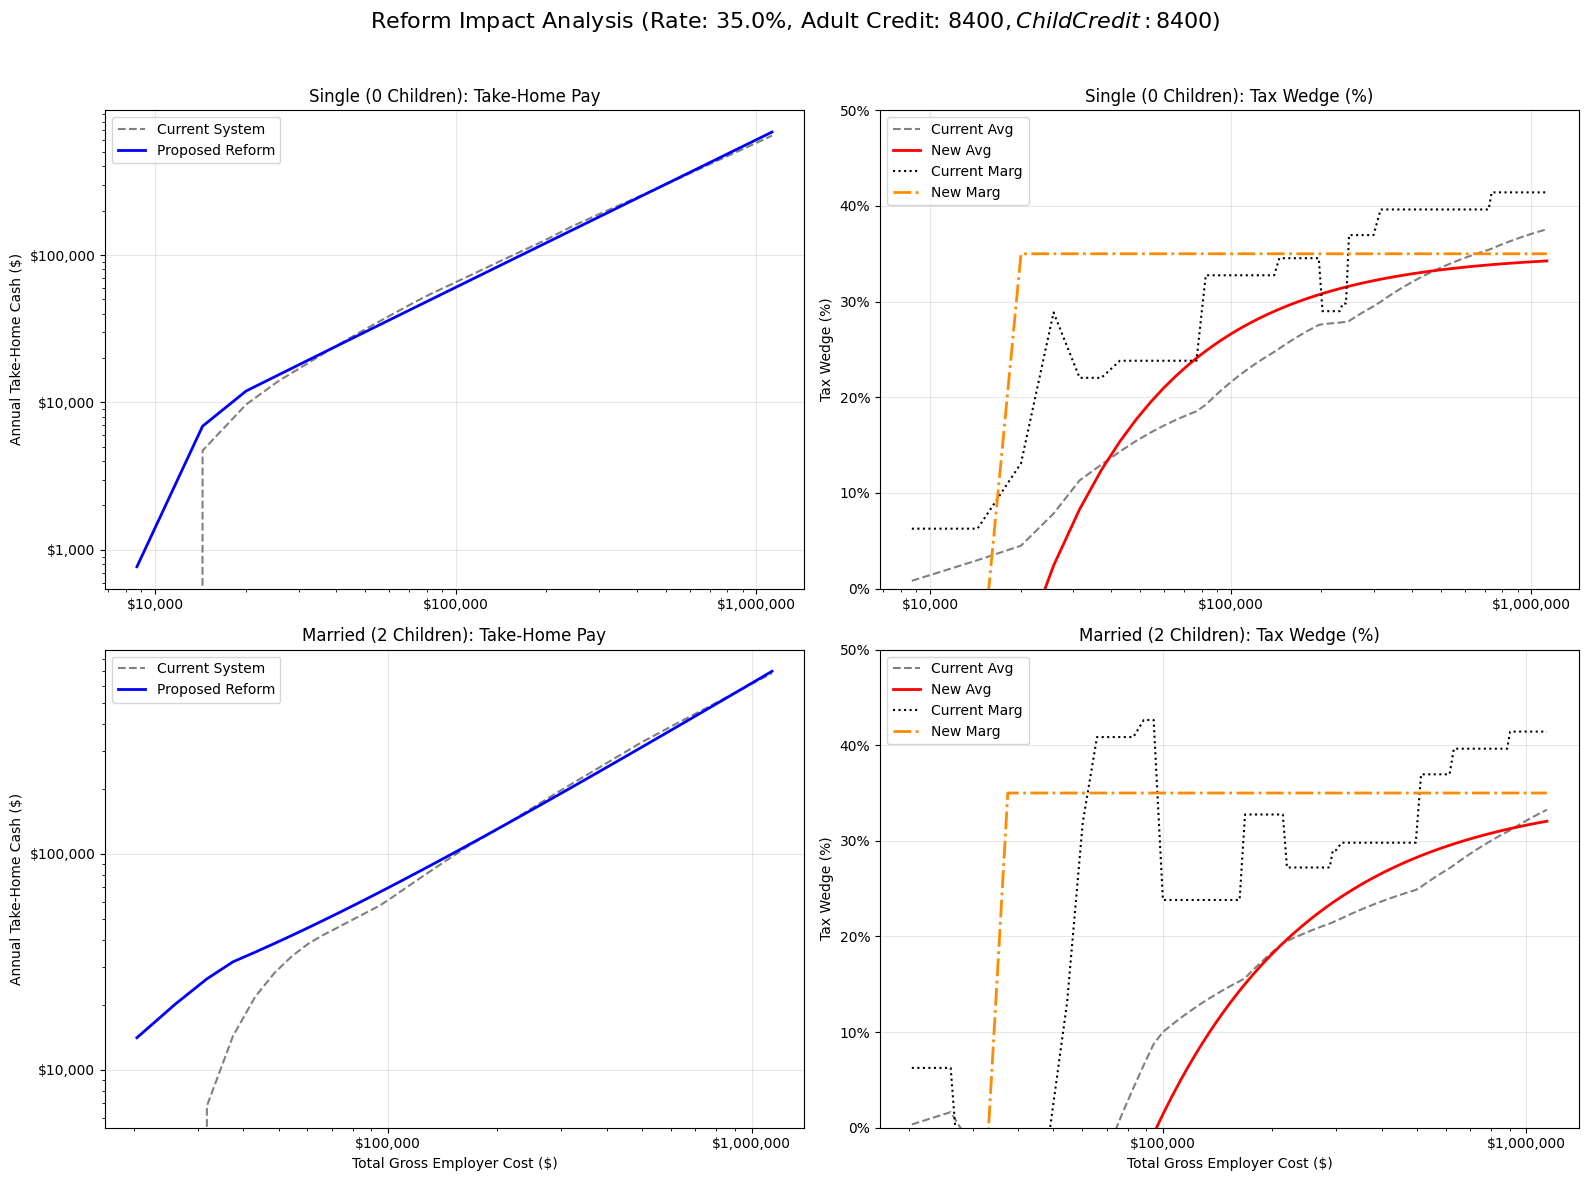

Plot saved successfully as 'Reform_Impact_35pct_$8400.png'


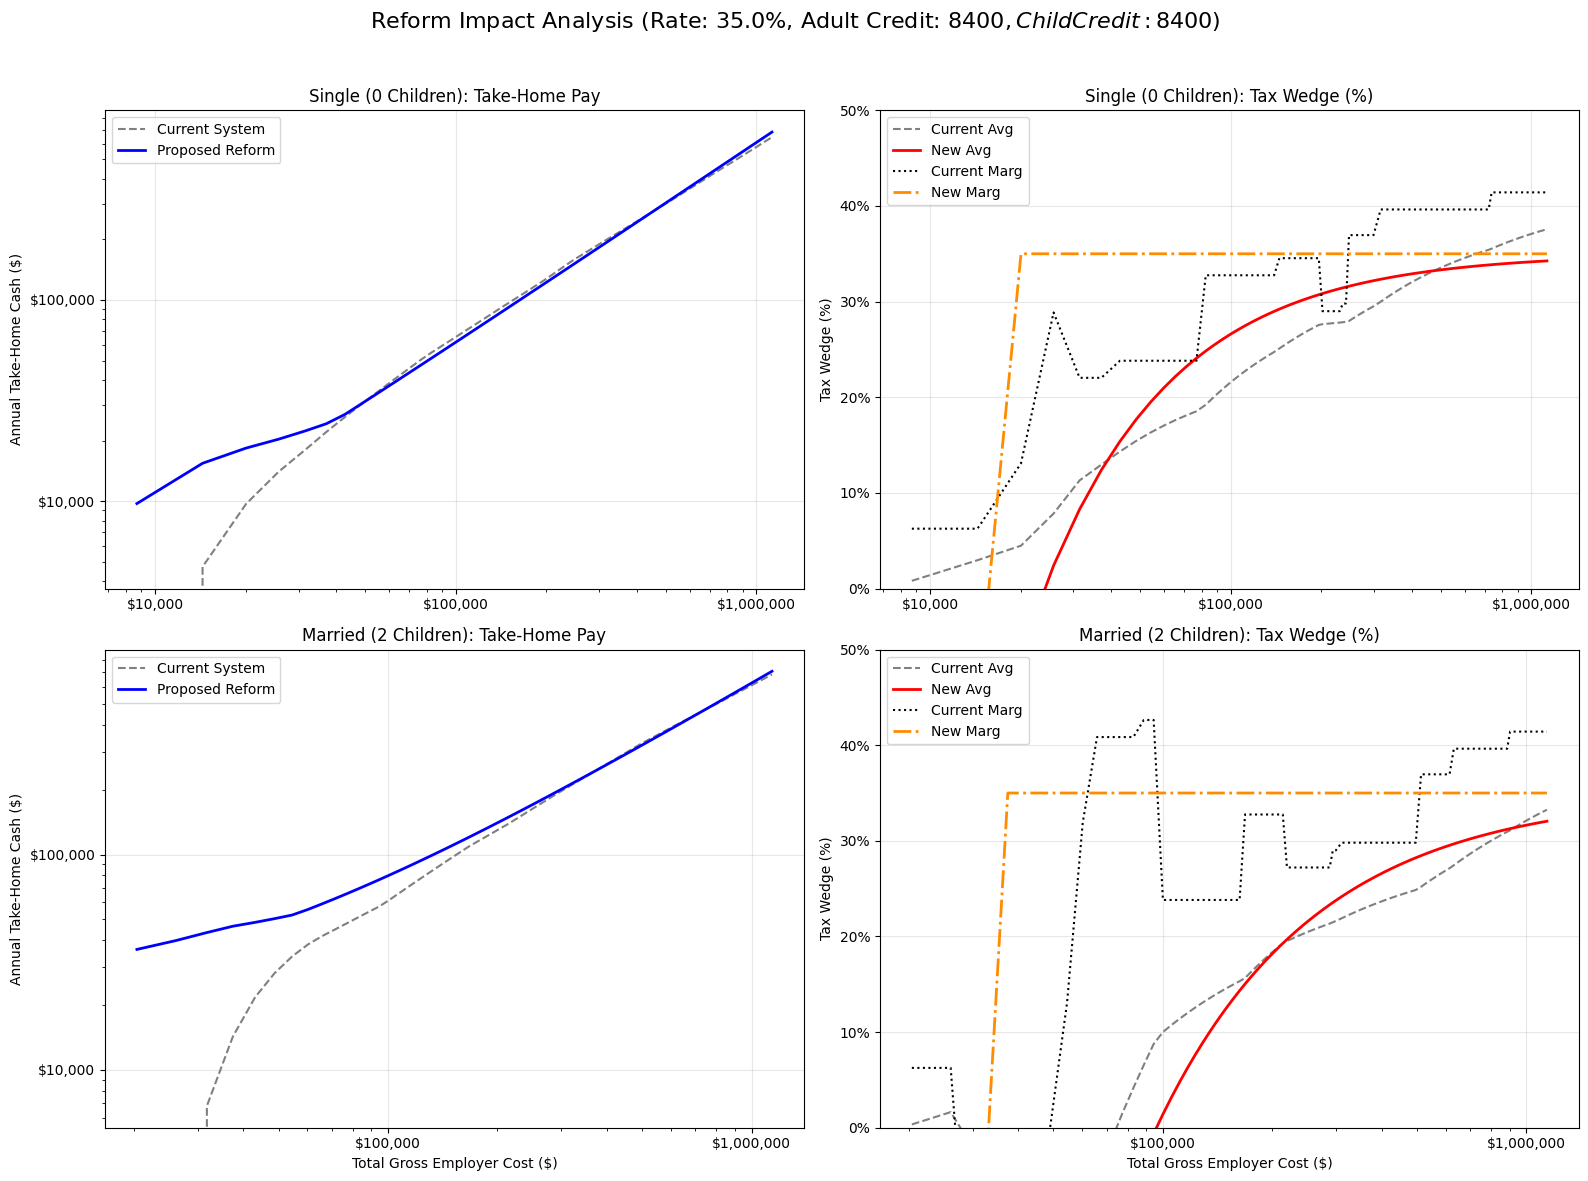

In [4]:
from tax_reform_utils import calculate_tax_wedge, plot_reform_impact

# Let's visualize the revenue neutral $4800 / 25% scenario
plot_reform_impact(rate=0.35, adult_credit=8400, child_credit=8400, health_reform = False)

plot_reform_impact(rate=0.35, adult_credit=8400, child_credit=8400, health_reform = True)


In [4]:
print(defneutral)

30.0%  $3600    0.66824
32.5%  $6000    0.50540
35.0%  $7200    0.68648
dtype: float64


Plot saved successfully as 'Reform_Impact_30pct_$3600.0.png'


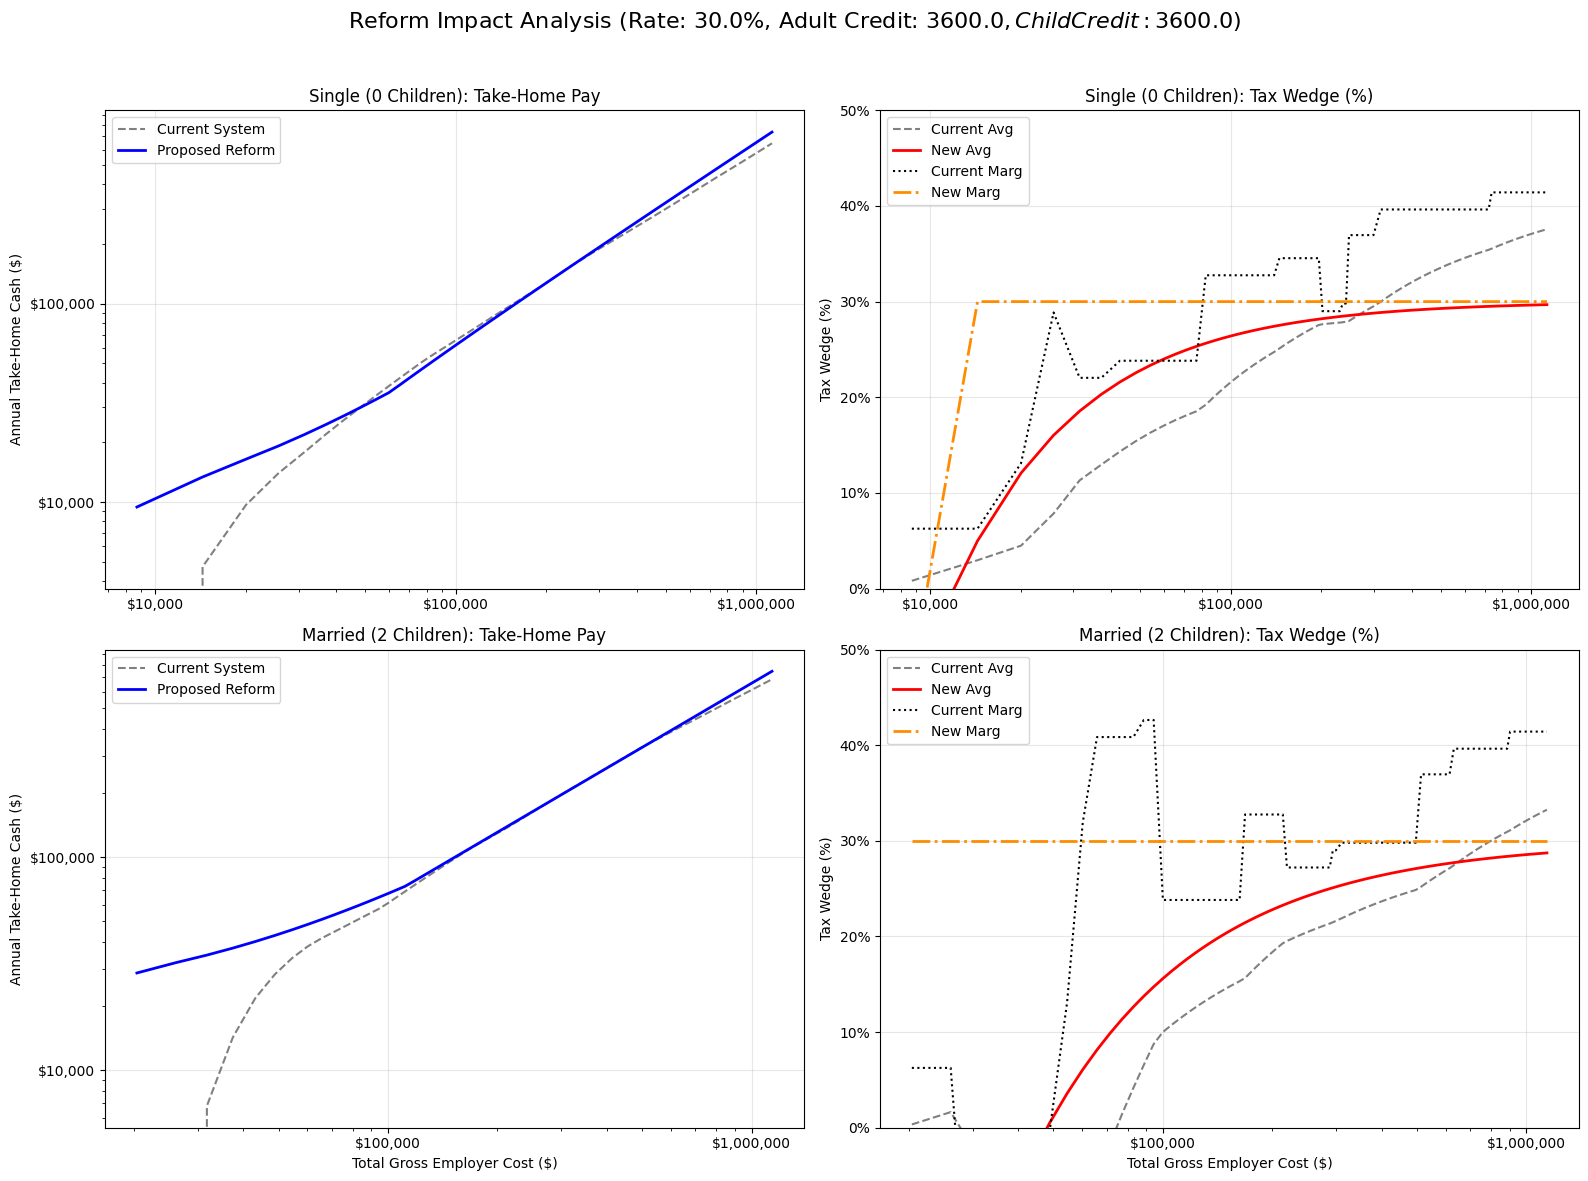

Plot saved successfully as 'Reform_Impact_32pct_$6000.0.png'


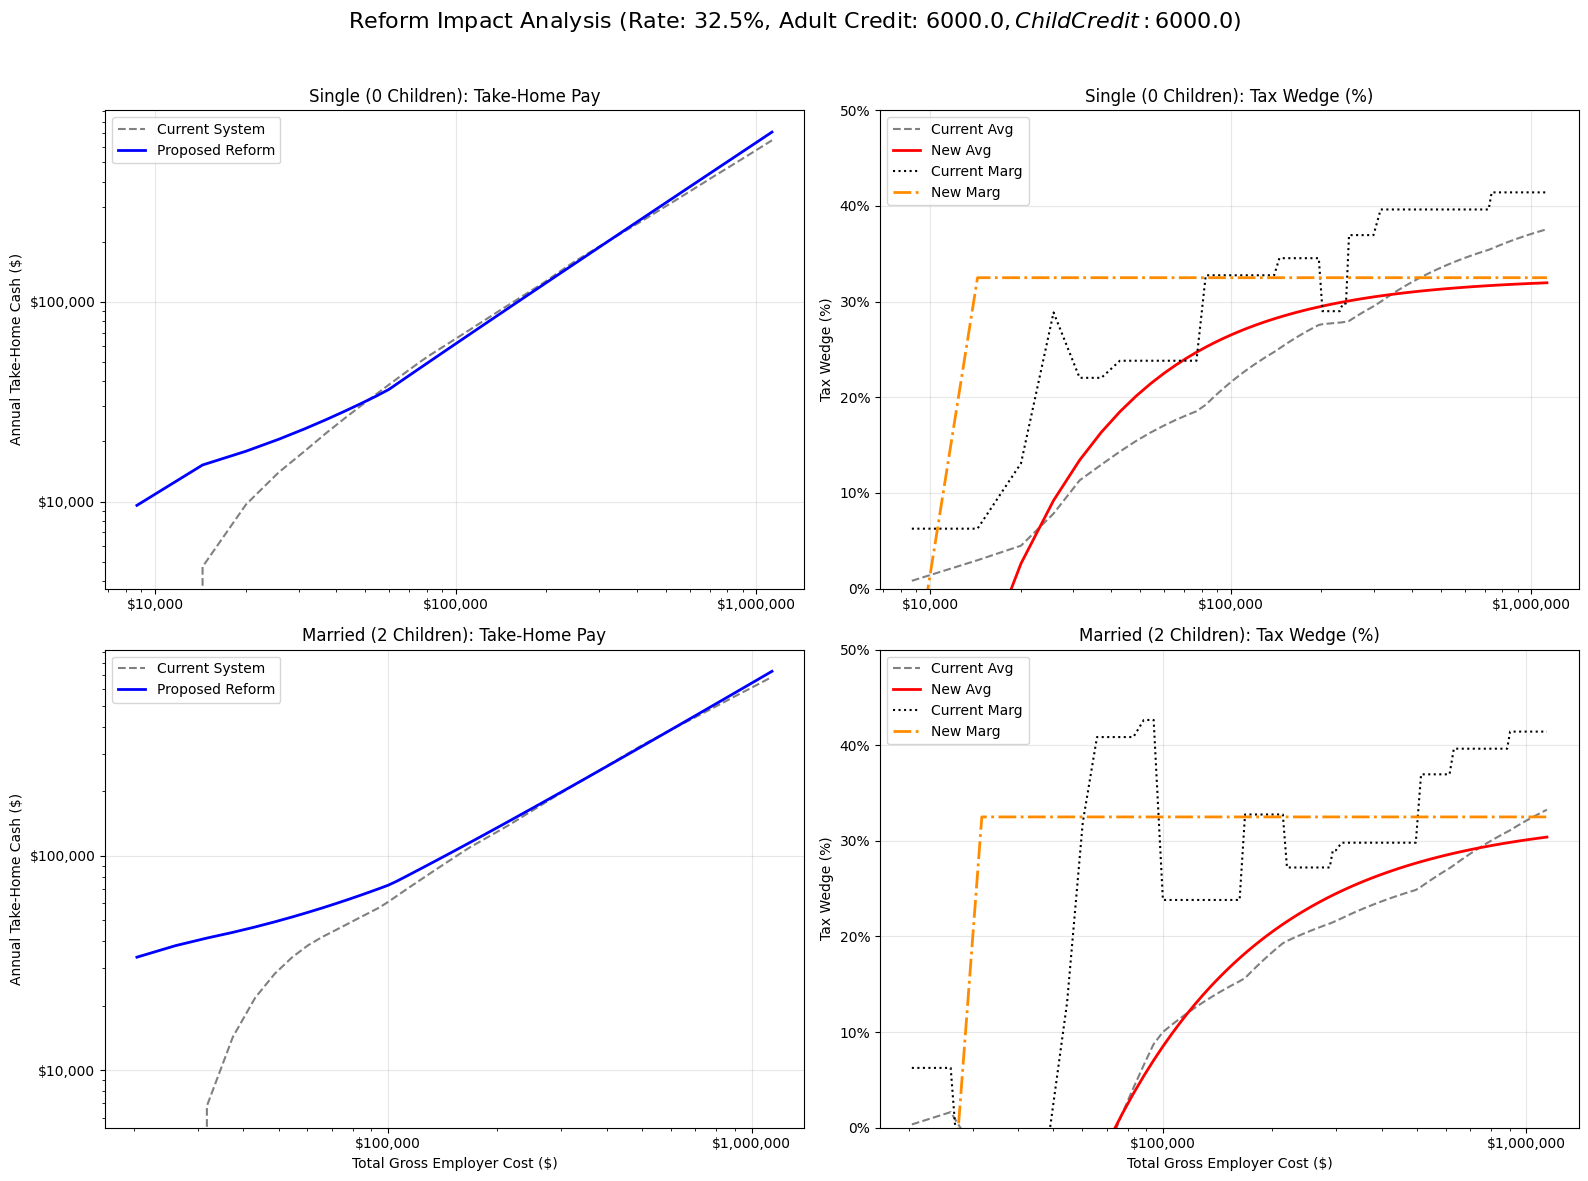

Plot saved successfully as 'Reform_Impact_35pct_$7200.0.png'


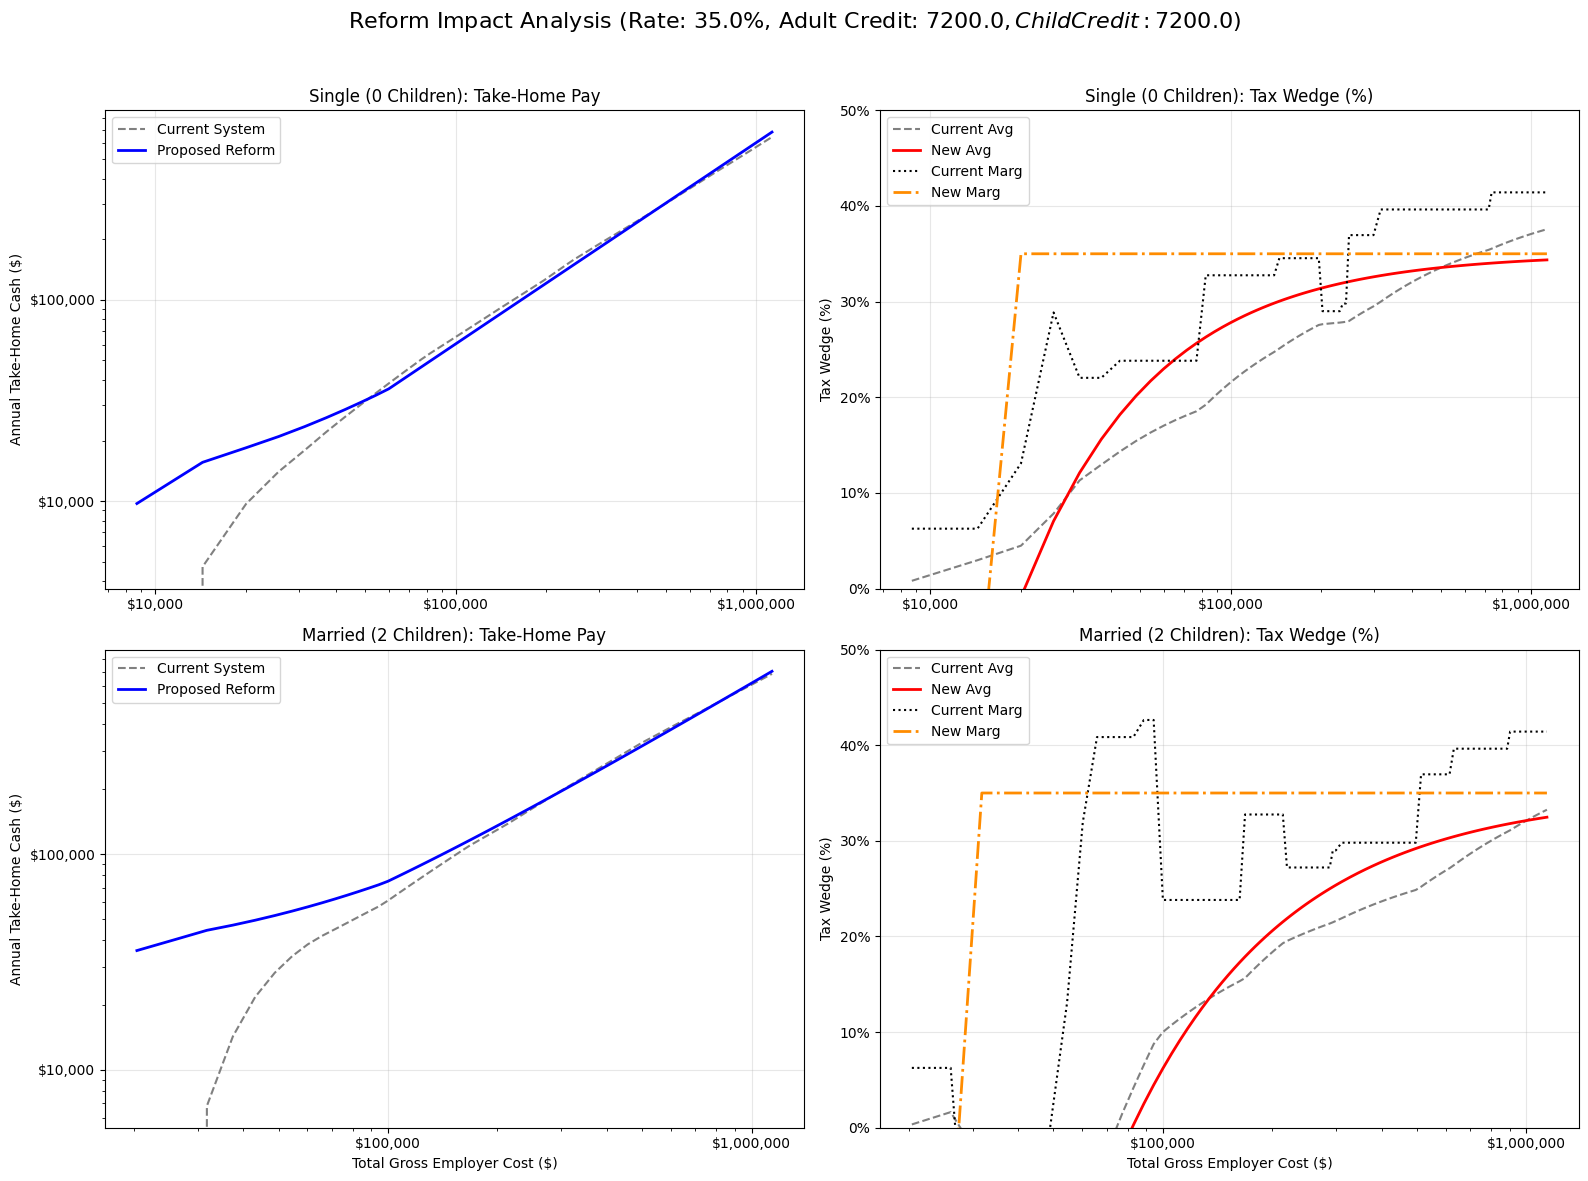

In [3]:
from tax_reform_utils import calculate_tax_wedge, plot_reform_impact

for rate, credit in combinations:
    rate = float(rate.strip('%')) / 100
    adult_credit = child_credit = float(credit.strip('$'))
    plot_reform_impact(rate, adult_credit, child_credit, health_reform = True)
    




## 5. Healthcare Insurance Reform

A separate reform for healthcare insurance proposes that the average insurance premium per person will be $7,700 yearly for each adult. The government will provide subsidies that cap an individual's premium contribution at 25% of their disposable income (defined as income above the 2024 Federal Poverty Level for their family size).

In [18]:
from tax_reform_utils import calculate_healthcare_subsidy

print('--- Healthcare Reform Examples ---')
print('1. Single Adult earning $30,000')
res1 = calculate_healthcare_subsidy(30000, 'single', 0)
print(f"  FPL: ${res1['fpl']:,} | Disposable Income: ${res1['disposable_income']:,.0f}")
print(f"  Premium: ${res1['total_premium']:,} | Individual Pays: ${res1['individual_contribution']:,.0f} | Gov Subsidy: ${res1['government_subsidy']:,.0f}\n")

print('2. Married Family of 4 earning $60,000')
res2 = calculate_healthcare_subsidy(60000, 'married', 2)
print(f"  FPL: ${res2['fpl']:,} | Disposable Income: ${res2['disposable_income']:,.0f}")
print(f"  Premium: ${res2['total_premium']:,} | Individual Pays: ${res2['individual_contribution']:,.0f} | Gov Subsidy: ${res2['government_subsidy']:,.0f}\n")

print('3. Married Family of 4 earning $150,000')
res3 = calculate_healthcare_subsidy(150000, 'married', 2)
print(f"  FPL: ${res3['fpl']:,} | Disposable Income: ${res3['disposable_income']:,.0f}")
print(f"  Premium: ${res3['total_premium']:,} | Individual Pays: ${res3['individual_contribution']:,.0f} | Gov Subsidy: ${res3['government_subsidy']:,.0f}\n")


--- Healthcare Reform Examples ---
1. Single Adult earning $30,000
  FPL: $15,060 | Disposable Income: $14,940
  Premium: $7,700 | Individual Pays: $3,735 | Gov Subsidy: $3,965

2. Married Family of 4 earning $60,000
  FPL: $31,200 | Disposable Income: $28,800
  Premium: $15,400 | Individual Pays: $7,200 | Gov Subsidy: $8,200

3. Married Family of 4 earning $150,000
  FPL: $31,200 | Disposable Income: $118,800
  Premium: $15,400 | Individual Pays: $15,400 | Gov Subsidy: $0



In [11]:
from tax_reform_utils import calculate_healthcare_subsidy

res3 = calculate_healthcare_subsidy(34439*.65, 'single', 0)
print(f"  FPL: ${res3['fpl']:,} | Disposable Income: ${res3['disposable_income']:,.0f}")
print(f"  Premium: ${res3['total_premium']:,} | Individual Pays: ${res3['individual_contribution']:,.0f} | Gov Subsidy: ${res3['government_subsidy']:,.0f}\n")



print(calculate_tax_wedge(2500, status='single', num_children=0, rate=0.25, adult_credit=1200, child_credit=1200, health_reform=False))
print(calculate_tax_wedge(2500, status='single', num_children=0, rate=0.25, adult_credit=1200, child_credit=1200, health_reform=True))



  FPL: $15,060 | Disposable Income: $7,325
  Premium: $7,700 | Individual Pays: $2,930 | Gov Subsidy: $4,770

{'gross_cost': 10380.5, 'current_take_home': 1132.0, 'current_wedge': 1.6858532825971773, 'new_take_home': -88.125, 'new_wedge': 13.439863205047928, 'current_tax': 175.0, 'new_tax': 1395.125}
{'gross_cost': 10380.5, 'current_take_home': 1132.0, 'current_wedge': 1.6858532825971773, 'new_take_home': 8862.875, 'new_wedge': 13.439863205047928, 'current_tax': 175.0, 'new_tax': 1395.125}
